In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

import sys
sys.path.append("..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()
import types

In [2]:
import polars as pl

In [3]:
folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Papers/Multicolour/Figure1'

In [4]:
data = pl.read_ods(os.path.join(folder, 'Data.ods'))

In [5]:
Ximea_data = data.filter(pl.col("Company") == "Ximea")
Thorlabs_data = data.filter(pl.col("Company") == "Thorlabs")

In [7]:
np.argmax(data['Peak QY'])

10

In [8]:
data[10]

Model,Year,RMS,Peak QY,Company
str,i64,f64,f64,str
"""MT023CG-SY""",2014,7.36,0.7,"""Ximea"""


In [22]:
readnoise_parameters = np.array([13.34, 7.36, 2.68])
QY_parameters = np.array([0.48, 0.7, 0.67])
dyes = ['ATTO 488', 'ATTO 565', 'ATTO 647N']
n_photon = 3000
n_background = 10
pixel_size = 69
NA = 1.49

notch_filter = 'semrock-nf03-405-488-561-635e'
dichroic_mirror = 'semrock-di03-r405-488-561-635-t1-25x36'
nilered_filter = 'semrock-ff01-650-200-25'
shortpass_filter = 'semrock-bsp01-785r'
filters = [notch_filter, dichroic_mirror, shortpass_filter]


In [10]:
import types
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma" :  1.5}
smoothing_function.extent =  1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [25]:
R, G, B, wavelength = S_F.getpixelefficiency()
photon_assumption = 4000
n_bootstrap = 1000
dye = 'ATTO 647N'
gain = 0.5
read_noises = np.arange(1, 10, 0.5)
peak_QYs = np.arange(0.4, 1, 0.05)

RN, QY = np.meshgrid(read_noises, peak_QYs)
molecule_detection_efficiency = np.zeros(np.hstack([RN.shape, n_bootstrap]))


In [ ]:
RN.shape

In [ ]:
R, G, B, wavelength = S_F.getpixelefficiency()
photon_assumption = 4000
dye = 'ATTO 647N'
gain = 0.5
read_noises = np.arange(1, 10, 0.5)
peak_QYs = np.arange(0.4, 1, 0.05)
n_bootstrap = 1000


RN, QY = np.meshgrid(read_noises, peak_QYs)
molecule_detection_efficiency = np.zeros(np.hstack([RN.shape, n_bootstrap]))

R, G, B, wavelength = S_F.getpixelefficiency()
image_size = 120 # 12 * 10, grid of 10*10 molecules
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
n_background = 4
pixel_size = 69
NA = 1.49
camera_parameters = {}
camera_parameters["masks"] = masks
camera_parameters["gain"] = np.full((image_size, image_size), gain)
camera_parameters["offset"] = np.full((image_size, image_size), 32)
camera_parameters["rqe"] = np.full((image_size, image_size), 1)
camera_parameters["pixel_order"] = ['B', 'G', 'R']
camera_parameters["pixel_order_indices"] = [0, 1, 2]
pixel_QYs = np.vstack([B, G, R])


molecule_positions = np.linspace(6*pixel_size, (120-6)*pixel_size, 10)
molecule_X, molecule_Y = np.meshgrid(molecule_positions, molecule_positions)
molecule_X = molecule_X.ravel(); molecule_Y = molecule_Y.ravel()

ishape, jshape = RN.shape
for i in np.arange(ishape):
    for j in np.arange(jshape):
        readnoise = RN[i, j]
        quantum_yield = QY[i, j]
        print(
                        "Simulation of readnoise {}, QY {}".format(
                            readnoise, quantum_yield
                        ),
                        end="\r",
                        flush=True,
                    )
    
        camera_parameters["readnoise"] = np.full((image_size, image_size), readnoise)
        variance = np.square(gain*readnoise)
        camera_parameters["variance"] = np.full((image_size, image_size), variance)
        scaling_factor = quantum_yield/np.max(pixel_QYs)
        camera_parameters["pixel_QYs"] = np.vstack([B, G, R])*scaling_factor
        
        n_photons = {}
        s = 1
        n_photons[dye] = np.full(s, photon_assumption)
        
        dye_matrix = np.zeros([1, len(wavelength)])
        
        x0y0 = {}
        
        average_emission_wavelengths, dye_pixel_efficiency = S_F.get_pixel_fractions_dye_and_filters(dye, filters, wavelength, camera_parameters["pixel_QYs"])
        x0y0[dye] = np.zeros([s, 2, len(molecule_X)])
        x0y0[dye][0, :, :] = np.array([molecule_X, molecule_Y])
        for k in np.arange(n_bootstrap):
            image, _, _ =  MSF.gen_camera_image_stack(camera_parameters, wavelength,
                                    average_emission_wavelengths, dye_pixel_efficiency, 
                                    n_photons, x0y0, smoothing_function=smoothing_function,
                                    background_photons=n_background, NA=NA, pixel_size=pixel_size, 
                                    return_normal_image=False,)
            points = SD_F.detect_puncta_in_image(image, pfa=1e-3, wavelength=0.7, NA=1.49)
            molecule_detection_efficiency[i, j, k] = len(points)/len(molecule_X)

In [ ]:
molecule_detection_efficiency_mean = np.mean(molecule_detection_efficiency, axis=-1)
molecule_detection_efficiency_std = np.std(molecule_detection_efficiency, axis=-1)

In [ ]:
limits = 90
limit_level = molecule_detection_efficiency_mean*100
limit_level[limit_level < limits] = 0
plt.imshow(limit_level, origin="lower");
plt.xticks(np.arange(len(read_noises))[::2], np.around(read_noises, 1)[::2])
plt.yticks(np.arange(len(peak_QYs)), np.around(peak_QYs, 2))


plt.colorbar()

In [26]:
R, G, B, wavelength = S_F.getpixelefficiency()
image_size = 12
images_for_figures = np.zeros([len(readnoise_parameters), len(dyes), image_size, image_size])

for i, readnoise in enumerate(readnoise_parameters):
    camera_parameters = {}
    masks = M_F.get_masks(size_x=image_size, size_y=image_size)
    gain = 0.5
    camera_parameters["gain"] = np.full((image_size, image_size), gain)
    camera_parameters["offset"] = np.full((image_size, image_size), 32)
    readnoise = readnoise
    camera_parameters["readnoise"] = np.full((image_size, image_size), readnoise)
    variance = np.square(gain*readnoise)
    camera_parameters["variance"] = np.full((image_size, image_size), variance)
    camera_parameters["rqe"] = np.full((image_size, image_size), 1)
    pixel_QYs = np.vstack([B, G, R])
    scaling_factor = QY_parameters[i]/np.max(pixel_QYs)
    camera_parameters["pixel_QYs"] = np.vstack([B, G, R])*scaling_factor
    camera_parameters["pixel_order"] = ['B', 'G', 'R']
    camera_parameters["pixel_order_indices"] = [0, 1, 2]
    camera_parameters["masks"] = M_F.get_masks(size_x=image_size, size_y=image_size)
    for j, dye in enumerate(dyes):
        n_photons = {}
        s = 1
        n_photons[dye] = np.full(s, n_photon)
        #n_photons["CF680"] = np.full(s, 5000)
        
        dye_matrix = np.zeros([1, len(wavelength)])
        
        x0y0 = {}
        max = pixel_size * image_size
        
        average_emission_wavelengths, dye_pixel_efficiency = S_F.get_pixel_fractions_dye_and_filters(dye, filters, wavelength, camera_parameters["pixel_QYs"])
        center = max / 2
        scaling = 1000
        
        image_dim = pixel_size * np.array(camera_parameters["gain"].shape)
        x0 = np.full(s, 6*69)
        y0 = np.full(s, 6*69)
        
        for dye in n_photons:
            x0y0[dye] = np.zeros([s, 2, 1])
            x0y0[dye][:, :, :] = np.array([[x0, y0]]).T
        images_for_figures[i, j, :, :], _, _ =  MSF.gen_camera_image_stack(camera_parameters, wavelength,
                            average_emission_wavelengths, dye_pixel_efficiency,
                            n_photons, x0y0, background_photons=4, smoothing_function=smoothing_function,
                            NA=NA, pixel_size=pixel_size, 
                            return_normal_image=False,)
        images_for_figures[i, j, :, :] = images_for_figures[i, j, :, :].clip(0, np.inf)

/tmp/ipykernel_511665/2607748893.py:27: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c


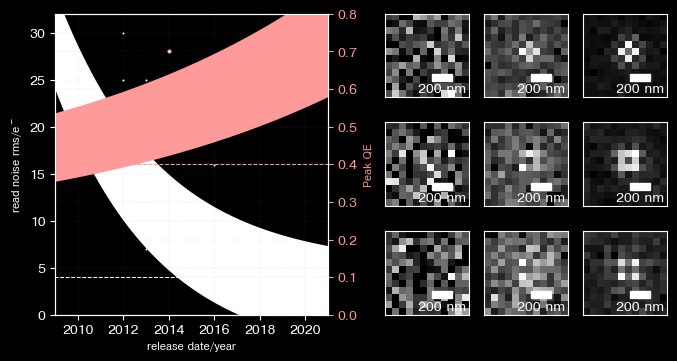

In [27]:
from matplotlib.gridspec import GridSpec

from scipy.interpolate import make_smoothing_spline
from scipy.optimize import curve_fit

fig = plt.figure(layout="constrained", figsize=(6.69, 3.5))
plt.style.use('dark_background')


gs = GridSpec(3, 6, figure=fig)

axs = fig.add_subplot(gs[:, :3])

axc1_1 = fig.add_subplot(gs[0, 3])
axc1_2 = fig.add_subplot(gs[1, 3])
axc1_3 = fig.add_subplot(gs[2, 3])

axc2_1 = fig.add_subplot(gs[0, 4])
axc2_2 = fig.add_subplot(gs[1, 4])
axc2_3 = fig.add_subplot(gs[2, 4])

axc3_1 = fig.add_subplot(gs[0, 5])
axc3_2 = fig.add_subplot(gs[1, 5])
axc3_3 = fig.add_subplot(gs[2, 5])

def decay_func(x, a, b, c):
    return a * np.exp(-b * x) + c

def grow(x, a, b, c):
    return a* np.exp(b * x) + c

axs = plotter.scatter_plot(axs=axs, x=Ximea_data['Year'].to_numpy(), y=Ximea_data['RMS'].to_numpy(), facecolor='white')

axs = plotter.scatter_plot(axs=axs, x=Thorlabs_data['Year'].to_numpy(), y=Thorlabs_data['RMS'].to_numpy(),
                          yaxislabel='read noise rms/e$^-$',
                          xaxislabel='release date/year', facecolor='white')
axs.hlines(xmax=2025, xmin=2005, y=4, lw=0.75, color='white', ls='--')


x = data['Year'].to_numpy()-np.min(data['Year'].to_numpy())

y = data['RMS'].to_numpy()

fit, cov = curve_fit(decay_func, x, y, p0=[30, 10, 0])
grid = np.linspace(2009, 2021, 400)-2009
p = decay_func(grid, fit[0], fit[1], fit[2])
yerror = np.full_like(len(grid), np.max(p*0.2))
axs = plotter.line_error_plot(axs=axs, x=grid+2009, y=p, yerror=yerror, yaxislabel=r'read noise rms/e$^-$',
                       xaxislabel='release date/year', ls='--', alpha=1, color='white')

ax2 = axs.twinx()

ax2 = plotter.scatter_plot(axs=ax2, x=Thorlabs_data['Year'].to_numpy(), y=Thorlabs_data['Peak QY'].to_numpy(),
                          yaxislabel='Peak QE',
                          xaxislabel='release date/year',
                          edgecolor='#ff9a9a')

ax2 = plotter.scatter_plot(axs=ax2, x=Ximea_data['Year'].to_numpy(), y=Ximea_data['Peak QY'].to_numpy(),
                          yaxislabel='Peak QE',
                          xaxislabel='release date/year',
                          edgecolor='#ff9a9a')

ax2.hlines(xmax=2025, xmin=2005, y=0.4, lw=0.75, color='#ff9a9a', ls='--')

x = data['Year'].to_numpy()-np.min(data['Year'].to_numpy())

y = data['Peak QY'].to_numpy()

fit, cov = curve_fit(grow, x, y, p0=[0.5, 0.2, 0.4])
grid = np.linspace(2009, 2021, 400)-2009
p = grow(grid, fit[0], fit[1], fit[2])
yerror = np.full_like(len(grid), np.max(p*0.2))

ax2 = plotter.line_error_plot(axs=ax2, x=grid+2009, y=p, yerror=p*0.2, yaxislabel=r'Peak QE',
                       xaxislabel='release date/year', ls='--', color='#ff9a9a', alpha=1)

axs.set_ylim([0, 32])
axs.set_xlim([2009, 2021])

ax2.set_ylim([0, 0.8])

ax2.yaxis.label.set_color('#ff9a9a')
ax2.tick_params(axis='y', colors='#ff9a9a')

for i, axis_type in enumerate([axc1_1, axc1_2, axc1_3]):
    axis_type = plotter.image_plot(axs=axis_type, data=images_for_figures[0, i, :, :], scalebarsize=200, scalebarlabel='200 nm', cbar='off')

for i, axis_type in enumerate([axc2_1, axc2_2, axc2_3]):
    axis_type = plotter.image_plot(axs=axis_type, data=images_for_figures[1, i, :, :], scalebarsize=200, scalebarlabel='200 nm', cbar='off')

for i, axis_type in enumerate([axc3_1, axc3_2, axc3_3]):
    axis_type = plotter.image_plot(axs=axis_type, data=images_for_figures[2, i, :, :], scalebarsize=200, scalebarlabel='200 nm', cbar='off')

plt.savefig(os.path.join(folder, 'Figure_1_data_dB.svg'), format='svg', dpi=600)
plt.show()

In [ ]:
plt.plot(grid, grow(grid, 1, 0.2, 0))

In [ ]:
plt.scatter(Ximea_data['Year'].to_numpy(), Ximea_data['Peak QY'].to_numpy())

In [ ]:
from scipy.interpolate import make_splrep

In [ ]:
import numpy as np
image = np.arange(8*8).reshape(8, 8)

In [ ]:
from skimage.measure import block_reduce
from skimage.transform import rescale, resize, downscale_local_mean

In [ ]:
image

In [ ]:
resize(block_reduce(image, block_size=2), image.shape, anti_aliasing=False, order=0)

In [ ]:
x = wavelength
y = pixel_QYs[2, :]

In [ ]:
x.shape

In [ ]:
cs = make_splrep(x, y, s=1e-4)

In [ ]:
xs = np.linspace(np.min(wavelength), np.max(wavelength), 10000)

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4))

#ax.scatter(x, y, label='data', facecolors=None, color=None, s=2)

#ax.plot(x, cs(x), label="S", color='black')

ax.plot(xs, cs(xs, 1), label="S'")

ax.legend(loc='lower left', ncol=2)

plt.show()